In [ ]:
try:
    import google.colab
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

if IN_COLAB:
    print("Running in Google Colab")
else:
    print("Running locally or in another environment")

Running in Google Colab


In [ ]:
# Install the ARC-AGI SDK
!pip install -q arc-agi

# Clone the repo (skip if running locally)
import os

if IN_COLAB:
    os.chdir('/content')
    if not os.path.exists("arc-witness-envs"):
        !git clone https://github.com/Guanghan/arc-witness-envs.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.2/40.2 kB 725.8 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.1/7.1 MB 29.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
gradio 5.50.0 requires pillow<12.0,>=8.0, but you have pillow 12.2.0 which is incompatible.
Cloning into 'arc-witness-envs'...
remote: Enumerating objects: 676, done.
remote: Counting objects: 100% (676/676), done.
remote: Compressing objects: 100% (380/380), done.
remote: Total 676 (delta 364), reused 569 (delta 257), pack-reused 0 (from 0)
Receiving objects: 100% (676/676), 3.32 MiB | 28.13 MiB/s, done.
Resolving deltas: 100% (364/364), done.


In [ ]:

if os.path.basename(os.getcwd()) != "arc-witness-envs":
    os.chdir("arc-witness-envs")
print(f"Working directory: {os.getcwd()}")

Working directory: /content/arc-witness-envs


In [ ]:
import sys, json, importlib
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from arcengine import GameAction, ActionInput, GameState

UP    = GameAction.ACTION1
DOWN  = GameAction.ACTION2
LEFT  = GameAction.ACTION3
RIGHT = GameAction.ACTION4
CONFIRM = GameAction.ACTION5
RESET = GameAction.RESET

ACTION_NAMES = {1: "UP", 2: "DOWN", 3: "LEFT", 4: "RIGHT", 5: "CONFIRM"}

# 16-color palette (index -> RGB)
PALETTE = {
    0:  [255, 255, 255],  # white
    1:  [204, 204, 204],  # light_gray
    2:  [153, 153, 153],  # gray
    3:  [102, 102, 102],  # dark_gray
    4:  [ 51,  51,  51],  # near_black
    5:  [  0,   0,   0],  # black
    6:  [229,  58, 163],  # magenta
    7:  [255, 123, 204],  # light_magenta
    8:  [249,  60,  49],  # red
    9:  [ 30, 147, 255],  # blue
    10: [136, 216, 241],  # light_blue
    11: [255, 220,   0],  # yellow
    12: [255, 133,  27],  # orange
    13: [146,  18,  49],  # maroon
    14: [ 79, 204,  48],  # green
    15: [163,  86, 214],  # purple
}

# Build matplotlib colormap from the palette
_colors_rgb = [np.array(PALETTE[i]) / 255.0 for i in range(16)]
WITNESS_CMAP = mcolors.ListedColormap(_colors_rgb)


def get_frame(game):
    """Get the current 64x64 grid from a game (as numpy array)."""
    frame_data = game.perform_action(ActionInput(id=RESET), raw=True)
    arr = frame_data.frame[0]
    return np.array(arr) if not isinstance(arr, np.ndarray) else arr


def act(game, action):
    """Perform an action and return (frame_array, frame_data)."""
    fd = game.perform_action(ActionInput(id=action), raw=True)
    arr = fd.frame[0]
    arr = np.array(arr) if not isinstance(arr, np.ndarray) else arr
    return arr, fd


def show_grid(grid, title="", ax=None):
    """Display a 64x64 color-index grid with the Witness palette."""
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 4))
    ax.imshow(grid, cmap=WITNESS_CMAP, vmin=0, vmax=15,
              interpolation='nearest')
    ax.set_title(title, fontsize=10)
    ax.axis('off')


# Game registry: game_id -> (module_path, class_name)
GAME_REGISTRY = {
    f"tw{i:02d}": (f"environment_files.tw{i:02d}.tw{i:02d}", f"Tw{i:02d}")
    for i in range(1, 14)
}

def load_game(game_id, seed=0):
    """Load and return a game instance by ID."""
    mod_path, cls_name = GAME_REGISTRY[game_id]
    mod = importlib.import_module(mod_path)
    return getattr(mod, cls_name)(seed=seed)

print("Setup complete.")

Setup complete.


## 2. Visualize a Puzzle Level

Each game renders to a **64×64 pixel grid** with 16 indexed colors. Let’s look at the first level of `tw01` (PathDots) — draw a path through all yellow waypoints.

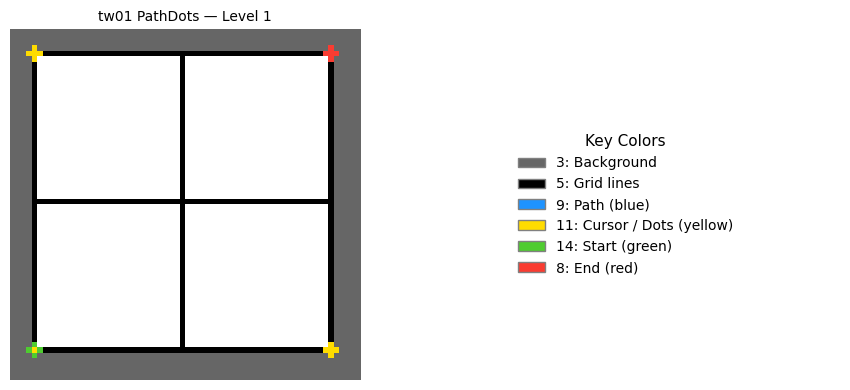

In [ ]:
game = load_game("tw01")
grid = get_frame(game)

fig, axes = plt.subplots(1, 2, figsize=(9, 4))

# Left: the rendered grid
show_grid(grid, "tw01 PathDots — Level 1", ax=axes[0])

# Right: palette legend
semantic = {
    3: "Background", 5: "Grid lines", 9: "Path (blue)",
    11: "Cursor / Dots (yellow)", 14: "Start (green)", 8: "End (red)",
}
patches = []
labels = []
for idx, name in semantic.items():
    color = np.array(PALETTE[idx]) / 255.0
    patches.append(plt.Rectangle((0, 0), 1, 1, fc=color, ec='gray'))
    labels.append(f"{idx}: {name}")
axes[1].legend(patches, labels, loc='center', fontsize=10,
               title="Key Colors", title_fontsize=11, frameon=False)
axes[1].axis('off')
plt.tight_layout()
plt.show()

## 3. Step-by-Step Gameplay

Solve `tw01` level 1 by executing actions one at a time. Watch the path grow on the grid.

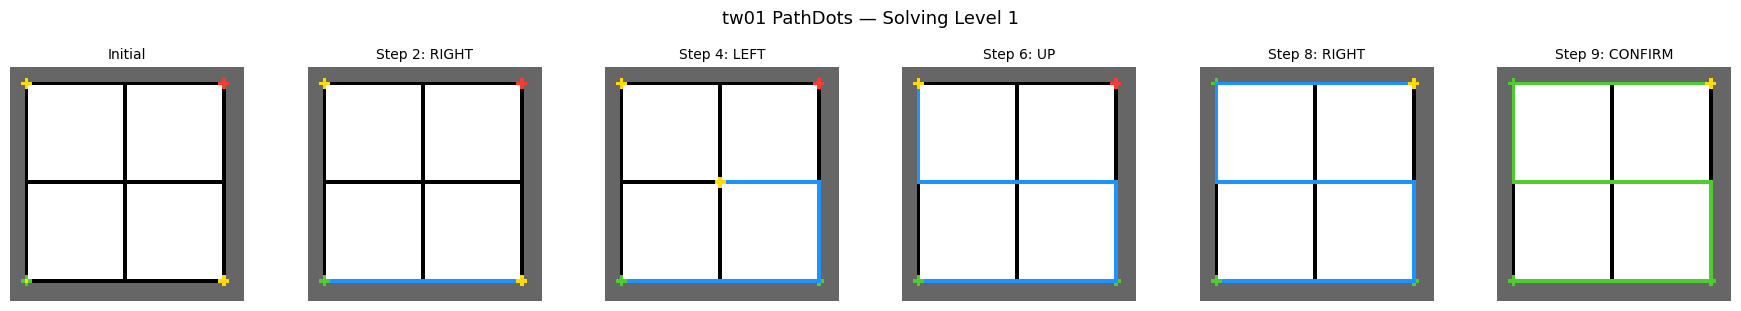

Levels completed: 1
Game state: GameState.NOT_FINISHED


In [ ]:
game = load_game("tw01")

# Known solution for tw01 level 1
solution = [RIGHT, RIGHT, UP, LEFT, LEFT, UP, RIGHT, RIGHT, CONFIRM]
action_labels = ["RIGHT", "RIGHT", "UP", "LEFT", "LEFT", "UP", "RIGHT", "RIGHT", "CONFIRM"]

# Collect frames at each step
frames = []
init_grid = get_frame(game)  # reset to get initial state
frames.append(("Start", init_grid.copy()))

for action, label in zip(solution, action_labels):
    grid, fd = act(game, action)
    frames.append((label, grid.copy()))

# Show key frames (every other + last two)
indices = [0, 2, 4, 6, 8, 9]  # Start, step 2, 4, 6, 8(RIGHT), 9(CONFIRM)
fig, axes = plt.subplots(1, len(indices), figsize=(3 * len(indices), 3))
for ax, i in zip(axes, indices):
    label, grid = frames[i]
    step_label = f"Step {i}: {label}" if i > 0 else "Initial"
    show_grid(grid, step_label, ax=ax)

plt.suptitle("tw01 PathDots — Solving Level 1", fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

print(f"Levels completed: {fd.levels_completed}")
print(f"Game state: {fd.state}")

## 4. All 13 Games at a Glance

Each game implements a different puzzle mechanic mapping to ARC-AGI [Core Knowledge](https://arxiv.org/abs/1911.01547) priors.

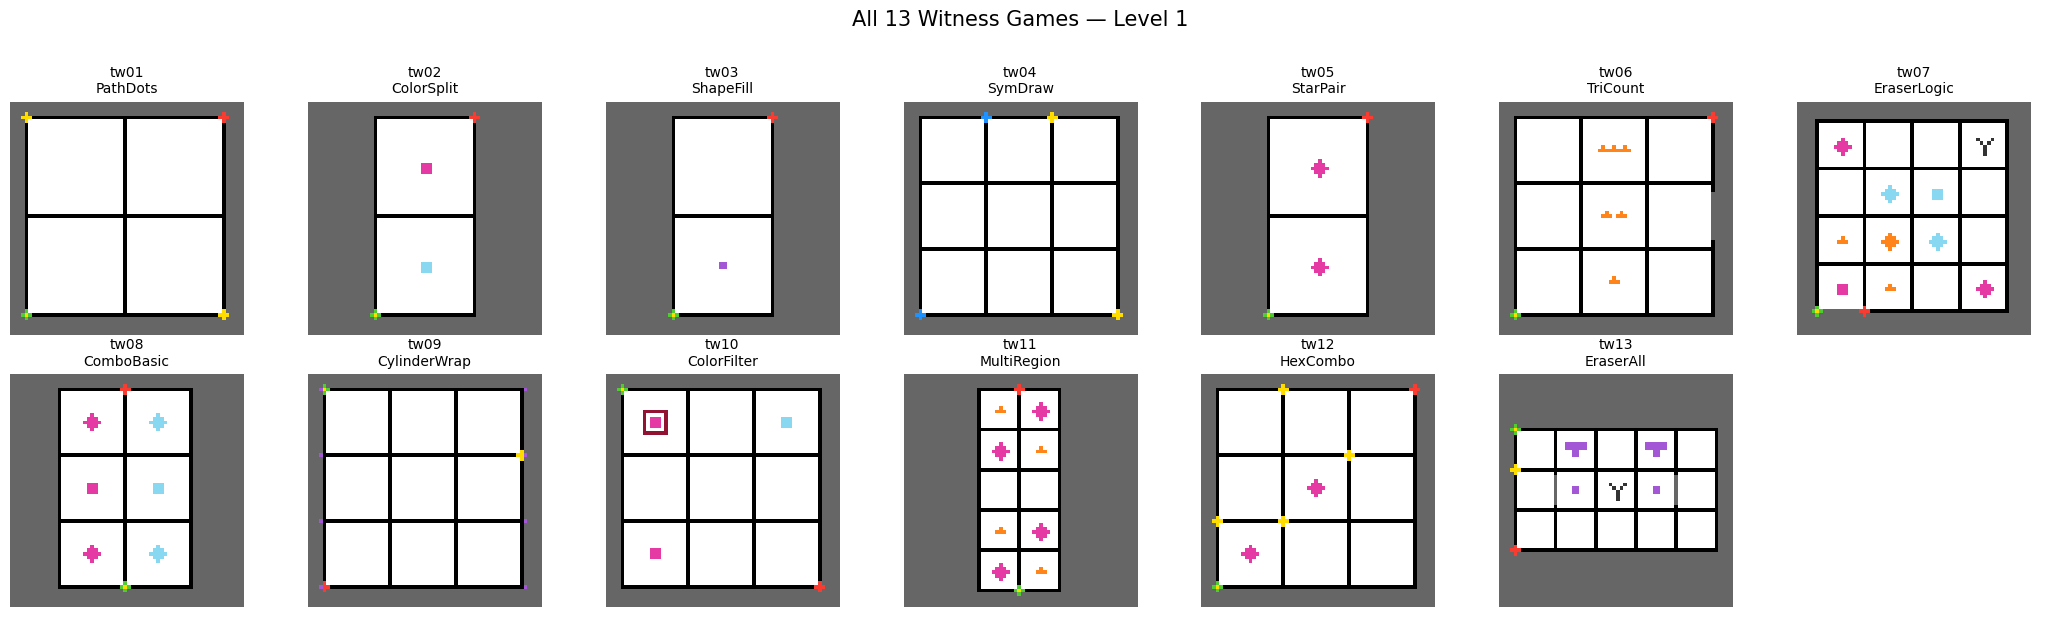

In [ ]:
game_titles = {
    "tw01": "PathDots",     "tw02": "ColorSplit",   "tw03": "ShapeFill",
    "tw04": "SymDraw",      "tw05": "StarPair",     "tw06": "TriCount",
    "tw07": "EraserLogic",  "tw08": "ComboBasic",   "tw09": "CylinderWrap",
    "tw10": "ColorFilter",  "tw11": "MultiRegion",  "tw12": "HexCombo",
    "tw13": "EraserAll",
}

fig, axes = plt.subplots(2, 7, figsize=(21, 6))
axes_flat = axes.flatten()

for i, (gid, title) in enumerate(game_titles.items()):
    game = load_game(gid)
    grid = get_frame(game)
    show_grid(grid, f"{gid}\n{title}", ax=axes_flat[i])

# Hide the extra subplot (14th cell in 2x7 grid)
axes_flat[13].axis('off')

plt.suptitle("All 13 Witness Games — Level 1", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

## 5. Dataset Statistics

Levels are stored in `levels/*.json`. Let’s visualize the distribution.

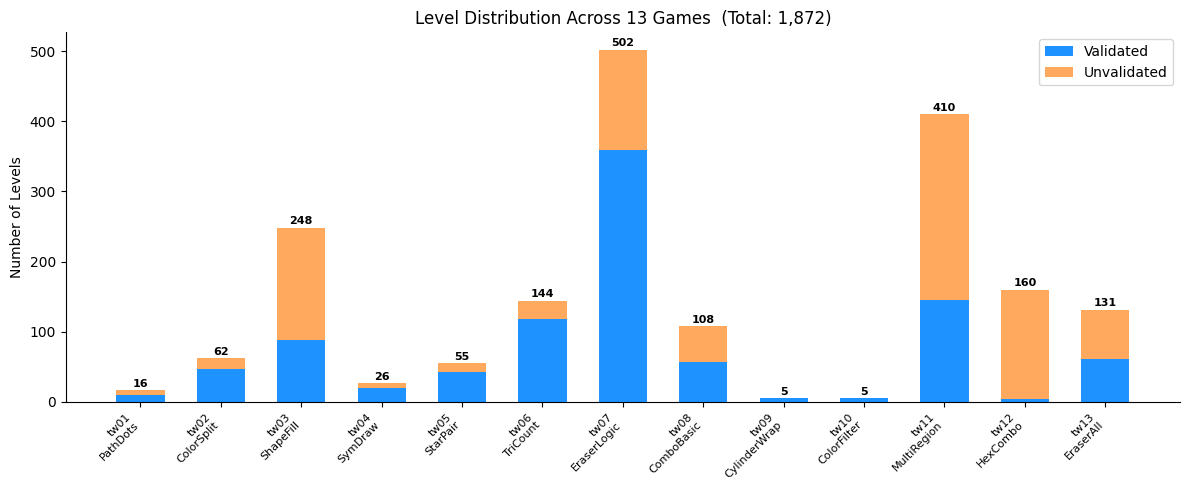

Total: 1,872 levels (959 validated + 913 unvalidated)


In [ ]:
stats = []
for gid in game_titles:
    path = f"levels/{gid}_levels.json"
    with open(path) as f:
        data = json.load(f)
    levels = data["levels"]
    validated = sum(1 for lv in levels if lv.get("validated", True))
    unvalidated = len(levels) - validated
    stats.append({"game": gid, "title": game_titles[gid],
                  "validated": validated, "unvalidated": unvalidated,
                  "total": len(levels)})

games = [s["game"] for s in stats]
val   = [s["validated"] for s in stats]
unval = [s["unvalidated"] for s in stats]

fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(games))
bar_w = 0.6
ax.bar(x, val, bar_w, label="Validated", color="#1e93ff")
ax.bar(x, unval, bar_w, bottom=val, label="Unvalidated", color="#ff851b", alpha=0.7)

# Annotate totals
for i, s in enumerate(stats):
    ax.text(i, s["total"] + 5, str(s["total"]), ha='center', fontsize=8, fontweight='bold')

ax.set_xticks(x)
ax.set_xticklabels([f"{s['game']}\n{s['title']}" for s in stats],
                    rotation=45, ha='right', fontsize=8)
ax.set_ylabel("Number of Levels")
ax.set_title(f"Level Distribution Across 13 Games  (Total: {sum(s['total'] for s in stats):,})")
ax.legend()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

print(f"Total: {sum(s['total'] for s in stats):,} levels "
      f"({sum(val)} validated + {sum(unval)} unvalidated)")

## 7. Plug In Your Own Agent

Replace the `my_agent` function below with your own policy. The interface is simple:
- **Observation**: 64×64 int array (color indices 0–15)
- **Action**: one of 5 discrete actions (UP / DOWN / LEFT / RIGHT / CONFIRM)

Not solved in 50 steps. Keep improving your agent!


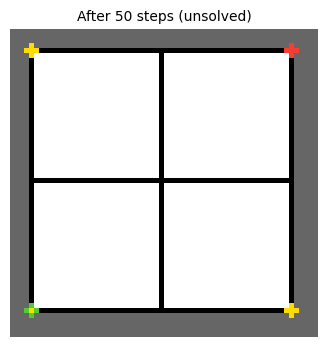

In [ ]:
import random

def my_agent(observation: np.ndarray) -> GameAction:
    """
    Your agent here.

    Args:
        observation: 64x64 numpy array of color indices (0-15)

    Returns:
        GameAction: one of ACTION1 (UP), ACTION2 (DOWN),
                    ACTION3 (LEFT), ACTION4 (RIGHT), ACTION5 (CONFIRM)
    """
    ACTIONS = [GameAction.ACTION1, GameAction.ACTION2,
               GameAction.ACTION3, GameAction.ACTION4, GameAction.ACTION5]

    return random.choice(ACTIONS)


# Run your agent on tw01
game = load_game("tw01")
fd = game.perform_action(ActionInput(id=RESET), raw=True)
initial_grid = np.array(fd.frame[0])

max_steps = 50
for step in range(max_steps):
    action = my_agent(initial_grid)
    grid, fd = act(game, action)
    initial_grid = grid

    if fd.levels_completed > 0:
        print(f"Level solved in {step + 1} steps!")
        show_grid(grid, f"Solved in {step+1} steps")
        plt.show()
        break
else:
    print(f"Not solved in {max_steps} steps. Keep improving your agent!")
    show_grid(grid, f"After {max_steps} steps (unsolved)")
    plt.show()

##Graph-Based Explorer Implementation
This agent systematically explores the state space using BFS, treating each unique 64x64 grid as a node in a graph.

In [ ]:
import numpy as np
from collections import deque
from dataclasses import dataclass, field
from typing import Dict, Optional, Set, Tuple, List
import hashlib

@dataclass
class GraphNode:
    """Represents a unique game state"""
    state_hash: str
    grid: np.ndarray
    parent: Optional['GraphNode'] = None
    action_from_parent: Optional[int] = None
    depth: int = 0

class GraphExplorer:
    """Systematically explores state space using BFS prioritization"""

    def __init__(self, env):
        self.env = env
        self.visited_states: Dict[str, GraphNode] = {}
        self.frontier = deque()
        self.action_history = []

    def get_state_hash(self, obs) -> str:
        """Generate a unique hash for the current game state"""
        # Use a stable representation (just the grid, not metadata)
        grid_bytes = obs.frame[0].tobytes()
        return hashlib.md5(grid_bytes).hexdigest()

    def explore(self, max_steps: int = 10000) -> Dict[str, GraphNode]:
        """
        Run BFS exploration to discover the maximum number of states.
        Always prioritizes moving to unvisited states.
        """
        # Start with initial state
        obs = self.env.reset()
        start_hash = self.get_state_hash(obs)
        start_node = GraphNode(
            state_hash=start_hash,
            grid=obs.frame.copy(),
            depth=0
        )
        self.visited_states[start_hash] = start_node
        self.frontier.append(start_node)

        steps = 0
        while self.frontier and steps < max_steps:
            current_node = self.frontier.popleft()

            # Get available actions
            actions = self.env.action_space

            for action in actions:
                # Skip RESET during exploration
                if action.name == "RESET":
                    continue

                # Execute action
                action_data = {}
                if action.is_complex():
                    # For click actions, use the center of the grid
                    action_data = {"x": 32, "y": 32}

                obs = self.env.step(action, data=action_data)
                steps += 1

                if obs is None:
                    continue

                # Check if we won
                if obs.state == "WIN":
                    print(f"🎉 Found win condition at step {steps}!")
                    return self.visited_states

                # Get hash of new state
                new_hash = self.get_state_hash(obs)

                # If this state is new, add it to the graph
                if new_hash not in self.visited_states:
                    new_node = GraphNode(
                        state_hash=new_hash,
                        grid=obs.frame.copy(),
                        parent=current_node,
                        action_from_parent=action.value,
                        depth=current_node.depth + 1
                    )
                    self.visited_states[new_hash] = new_node
                    self.frontier.append(new_node)

                    # Log discovery
                    print(f"Discovered new state {len(self.visited_states)} at depth {new_node.depth}")

                # Stop if step limit reached
                if steps >= max_steps:
                    break

            # Reset if we've exhausted the current frontier without progress
            if not self.frontier and steps < max_steps:
                print("Resetting to find new paths...")
                obs = self.env.reset()
                start_hash = self.get_state_hash(obs)
                if start_hash not in self.visited_states:
                    start_node = GraphNode(
                        state_hash=start_hash,
                        grid=obs.frame.copy(),
                        depth=0
                    )
                    self.visited_states[start_hash] = start_node
                    self.frontier.append(start_node)

        print(f"Exploration complete. Found {len(self.visited_states)} unique states.")
        return self.visited_states

    def find_path_to_state(self, target_hash: str) -> List[int]:
        """Reconstruct the action sequence to reach a target state"""
        if target_hash not in self.visited_states:
            return None

        path = []
        node = self.visited_states[target_hash]
        while node.parent:
            path.append(node.action_from_parent)
            node = node.parent
        return list(reversed(path))

###Hypothesis Tracker Logic

This component maintains a set of candidate rules about the game mechanics, ranking them by confidence.



In [ ]:
from enum import Enum
from typing import Any, Dict, List, Optional, Set, Tuple
from dataclasses import dataclass, field

class RuleType(Enum):
    """Types of rules the agent can discover"""
    COLLECT = "collect"        # Objects that disappear when touched
    OBSTACLE = "obstacle"      # Objects that cause reset/negative feedback
    GOAL = "goal"              # Objects that complete the level
    SWITCH = "switch"          # Objects that affect other objects
    PATH = "path_requirement"  # Path length or connectivity requirements
    COUNT = "count"            # Counting constraints (e.g., "collect exactly 3")

@dataclass
class Hypothesis:
    """A candidate rule about how the game works"""
    rule_type: RuleType
    objects: Set[Tuple[int, int]]  # Positions of relevant objects
    effects: Dict[str, Any]        # What happens when triggered
    confidence: float = 0.0
    evidence: List[str] = field(default_factory=list)
    counterevidence: List[str] = field(default_factory=list)

    def update_confidence(self):
        """Recalculate confidence based on evidence and counterevidence"""
        total = len(self.evidence) + len(self.counterevidence)
        if total == 0:
            self.confidence = 0.0
        else:
            self.confidence = len(self.evidence) / total

class HypothesisTracker:
    """
    Maintains a set of hypotheses about game rules.
    Tracks evidence for and against each hypothesis.
    """

    def __init__(self):
        self.hypotheses: Dict[str, Hypothesis] = {}
        self.confirmed_rules: Dict[str, Hypothesis] = {}
        self.object_tracking: Dict[Tuple[int, int], Dict[str, Any]] = {}

    def observe_transition(self,
                          pre_state: np.ndarray,
                          post_state: np.ndarray,
                          action: int,
                          reward: float,
                          win: bool):
        """
        Process an observed state transition and update hypotheses.
        """
        # Find which pixels changed
        changed = np.where(pre_state != post_state)
        disappeared = []
        appeared = []

        for y, x in zip(changed[0], changed[1]):
            if pre_state[y, x] != 0 and post_state[y, x] == 0:
                disappeared.append((x, y))
            elif pre_state[y, x] == 0 and post_state[y, x] != 0:
                appeared.append((x, y))

        # Update object tracking
        for pos in disappeared:
            self.object_tracking[pos] = {
                "last_seen": "disappeared",
                "trigger_action": action
            }

        # If something disappeared and we got a reward, it's probably a COLLECTIBLE
        if disappeared and reward > 0:
            self._update_hypothesis(
                RuleType.COLLECT,
                set(disappeared),
                {"reward": reward, "action": action},
                is_evidence=True
            )

        # If something disappeared and we lost/restarted, it's an OBSTACLE
        if disappeared and reward < 0:
            self._update_hypothesis(
                RuleType.OBSTACLE,
                set(disappeared),
                {"penalty": reward, "action": action},
                is_evidence=True
            )

        # If we won, the current object positions are GOAL candidates
        if win:
            current_objects = self._extract_objects(post_state)
            self._update_hypothesis(
                RuleType.GOAL,
                current_objects,
                {"win_condition": "reached"},
                is_evidence=True
            )

    def _update_hypothesis(self,
                          rule_type: RuleType,
                          objects: Set[Tuple[int, int]],
                          effect: Dict[str, Any],
                          is_evidence: bool):
        """Update or create a hypothesis based on new observation"""

        # Create a key for this hypothesis
        obj_key = tuple(sorted(objects))
        key = f"{rule_type.value}_{obj_key}"

        if key not in self.hypotheses:
            self.hypotheses[key] = Hypothesis(
                rule_type=rule_type,
                objects=objects,
                effects=effect
            )

        hyp = self.hypotheses[key]
        if is_evidence:
            hyp.evidence.append(str(effect))
        else:
            hyp.counterevidence.append(str(effect))
        hyp.update_confidence()

        # If confidence is high enough, consider it confirmed
        if hyp.confidence > 0.8 and key not in self.confirmed_rules:
            self.confirmed_rules[key] = hyp
            print(f"✅ Confirmed rule: {rule_type.value} on {objects}")

    def _extract_objects(self, grid: np.ndarray) -> Set[Tuple[int, int]]:
        """Extract all non-background objects from the grid"""
        objects = set()
        for y in range(grid.shape[0]):
            for x in range(grid.shape[1]):
                if grid[y, x] != 0:  # Background is color 0
                    objects.add((x, y))
        return objects

    def get_best_hypothesis(self) -> Optional[Hypothesis]:
        """Return the hypothesis with highest confidence"""
        if not self.hypotheses:
            return None

        return max(self.hypotheses.values(), key=lambda h: h.confidence)

    def get_untested_hypotheses(self) -> List[Hypothesis]:
        """Return hypotheses with no evidence yet"""
        return [h for h in self.hypotheses.values()
                if len(h.evidence) == 0 and len(h.counterevidence) == 0]

###Integrating Explorer and Hypothesis Tracker

Combine graph explorer and hypothesis tracker.

In [ ]:
class IntelligentARCExplorer:
    """
    Combines systematic exploration with hypothesis-driven decision making.
    """

    def __init__(self, env):
        self.env = env
        self.explorer = GraphExplorer(env)
        self.hypothesis_tracker = HypothesisTracker()
        self.current_plan = []
        self.best_known_goal = None

    def run(self, max_steps=10000):
        """Main agent loop"""
        obs = self.env.reset()

        for step in range(max_steps):
            # 1. Check if we have a plan from a confirmed hypothesis
            if self.current_plan:
                # Execute the next action in the plan
                action = self.current_plan.pop(0)
                print("action")
                print(action)
                pre_grid = obs.frame[0].copy() if obs else None
                obs = self.env.step(action)

                # Track the transition
                if pre_grid is not None and obs is not None:
                    self.hypothesis_tracker.observe_transition(
                        pre_grid, obs.frame[0], action.value,
                        reward=0,  # Would need to track actual reward
                        win=(obs.state == "WIN")
                    )
                continue

            # 2. Check if we have a confirmed rule to exploit
            confirmed = self.hypothesis_tracker.confirmed_rules
            if confirmed:
                # For COLLECT rules, create a plan to collect remaining objects
                for key, hypothesis in confirmed.items():
                    if hypothesis.rule_type == RuleType.COLLECT:
                        # Find uncollected objects and plan a path
                        # (In practice, you'd use the BFS graph to find paths)
                        print(f"🎯 Exploiting rule: collect {hypothesis.objects}")
                        # Create plan here...
                        pass

            # 3. Otherwise, continue systematic exploration
            # This uses the BFS frontier from the GraphExplorer
            if not self.current_plan:
                # Find an action that leads to an unexplored state
                for action in self.env.action_space:
                    # Test each action (simulated) to see if it leads to a new state
                    new_hash = self.explorer.get_state_hash(
                        self.env.step(action)
                    )
                    if new_hash not in self.explorer.visited_states:
                        self.current_plan = [action]
                        break
            print("state")
            print(new_hash)

            # Reset the environment if needed
            if obs and obs.state in ["WIN", "GAME_OVER"]:
                print("Level complete, resetting...")
                obs = self.env.reset()
                self.explorer = GraphExplorer(self.env)

        return self.hypothesis_tracker.confirmed_rules

In [ ]:
# arc agi3 method of interaction with the witness games


from arc_agi import Arcade, OperationMode
from arcengine import GameAction, GameState

# 1. Point to the directory containing the 'environment_files' folder
#    (e.g., the 'arc-witness-envs' directory you cloned)
arcade = Arcade(
    operation_mode=OperationMode.OFFLINE,
    environments_dir="/content/arc-witness-envs/environment_files",
)

# 2. Get the environment for a specific game (e.g., PathDots)
env = arcade.make(game_id="tw01")

# 3. Exploration

explorer = IntelligentARCExplorer(env)
confirmed_rules = explorer.run(max_steps=10000)


# 4. Get your final scorecard
scorecard = arcade.get_scorecard()
if scorecard:
    print(f"Final Score: {scorecard.score}")

INFO:arc_agi.scorecard:Initialized ScorecardManager with idle_for=0:15:00 and max_open_for=3 days, 0:00:00
2026-05-18 06:32:49 | INFO | Created new scorecard: cfc447a4-dd7d-4460-a67f-6a024334a305


INFO:arc_agi.base:Created new scorecard: cfc447a4-dd7d-4460-a67f-6a024334a305


2026-05-18 06:32:49 | INFO | Found latest version of tw01: tw01 (downloaded: 2026-03-05 00:00:00+00:00)


INFO:arc_agi.base:Found latest version of tw01: tw01 (downloaded: 2026-03-05 00:00:00+00:00)


Streaming output truncated to the last 5000 lines.
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action
GameAction.ACTION1
state
eb1954b7254481c89625010bea1df124
action